## **Installing Packages**

In [1]:
from IPython.display import display, HTML
from tqdm.notebook import tqdm
import subprocess

# --- Phase 1: Lightweight packages ---
phase1 = [
    "scikit-learn==1.5.2",
    "tabpfn",
    "catboost",
    "xgboost",
    "lightgbm",
    "datasets",
    "ucimlrepo",
    "ace_tools"
]

# --- Phase 2: Heavy or Git-based packages ---
phase2 = [
    "autogluon==0.8.2 --no-cache-dir --upgrade",
    "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"
]

# --- Function to install packages with live output ---
def install_packages(package_list, phase_name):
    logs = []
    display(HTML(f"<h3>🚀 Starting {phase_name}</h3>"))
    for pkg in tqdm(package_list, desc=f"{phase_name}", unit="pkg"):
        display(HTML(f"<b>Installing:</b> {pkg}"))
        process = subprocess.Popen(
            ["pip", "install", "--no-cache-dir", "--upgrade", pkg],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )
        output = ""
        for line in process.stdout:
            output += line
        process.wait()
        logs.append(f"📦 {pkg}\n{output}")
    return logs

# --- Run both phases ---
logs_phase1 = install_packages(phase1, "Phase 1: Core Packages")
logs_phase2 = install_packages(phase2, "Phase 2: Heavy/Git Packages")

# --- Display combined logs ---
all_logs = logs_phase1 + logs_phase2
scrollable_logs = (
    "<pre style='max-height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;'>"
    + "\n\n".join(all_logs) + "</pre>"
)
display(HTML(scrollable_logs))

Phase 1: Core Packages:   0%|          | 0/8 [00:00<?, ?pkg/s]

Phase 2: Heavy/Git Packages:   0%|          | 0/2 [00:00<?, ?pkg/s]

In [2]:
# # Install dependencies
# !pip install tabpfn autogluon catboost lightgbm xgboost pandas numpy matplotlib seaborn
# !git clone https://github.com/PriorLabs/tabpfn-extensions
# !pip install -e tabpfn-extensions[all]
# !pip install scikit-learn==1.5.2
# !pip install "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import catboost as cb
import lightgbm as lgb
import xgboost as xgb

# Optional imports with fallbacks
# AutoGluon
try:
    from autogluon.tabular import TabularPredictor
    AGLUON_AVAILABLE = True
except ImportError as e:
    print("Warning: AutoGluon import failed:", e)
    AGLUON_AVAILABLE = False

# TabPFN
# from tabpfn import TabPFNClassifier
# try:
#   from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier, AutoTabPFNRegressor
# except:
#   raise SystemError('Please restart the session to fix this import.')

from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier

/tmp/ipykernel_36/1619273419.py:5: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


In [4]:
# 3) Load dataset (update the file path as needed)
# abalone = '/kaggle/input/abalone-dataset/abalone.csv'
# df = pd.read_csv(abalone)
# target = 'Rings'

# Airfoil = '/kaggle/input/airfoil-selfnoise-dataset/AirfoilSelfNoise.csv'
# df = pd.read_csv(Airfoil)
# target = 'SSPL'

# auction = '/kaggle/input/auction-verification-dataset/data.csv'
# df = pd.read_csv(auction)
# target = 'verification.time'

# boston = '/kaggle/input/bostonhoustingmlnd/housing.csv'
# df = pd.read_csv(boston)
# target = 'MEDV'

# college = '/kaggle/input/college-data/data.csv'
# df = pd.read_csv(college)
# target = 'room_board'

# concrete = '/kaggle/input/concrete-compressive-strength-data-set/concrete_data.csv'
# df = pd.read_csv(concrete)
# target = 'concrete_compressive_strength'

housing = '/kaggle/input/housing-prices-dataset/Housing.csv'
df = pd.read_csv(housing)
target = 'price'

In [5]:
# 4) Dataset overview and information
print("Shape of the dataset:", df.shape)
df.info()
print("\nFirst few rows:")
display(df.head())
print("\nLast few rows:")
display(df.tail())
print("\nDescriptive statistics:")
display(df.describe(include='all').T)
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))
print("\nMemory usage per column:")
display(df.memory_usage(deep=True))
print("\nUnique value counts per column:")
display(df.nunique())
print("\nData types of each column:")
display(df.dtypes)

Shape of the dataset: (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

First few rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Last few rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished



Descriptive statistics:


...

Index                 132
price                4360
area                 4360
bedrooms             4360
bathrooms            4360
stories              4360
mainroad            32623
guestroom           32252
basement            32346
hotwaterheating     32180
airconditioning     32327
parking              4360
prefarea            32283
furnishingstatus    37461
dtype: int64


Unique value counts per column:


price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64


Data types of each column:


price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

### 5. Separate target and features

In [6]:
# Keep target vector separate from X
if target not in df.columns:
    raise KeyError(f"Target column '{target}' not found in dataframe.")
y = df[target]
X = df.drop(columns=target)

In [7]:
# --- FIX: clean the target to avoid NaN/Inf ---
y_num = pd.to_numeric(y, errors="coerce")  # coerce invalids to NaN
mask = np.isfinite(y_num.to_numpy())

dropped = (~mask).sum()
if dropped:
    print(f"[Target clean] Dropping {dropped} rows with non-finite labels (NaN/Inf).")

X = X.loc[mask].reset_index(drop=True)
y = y_num.loc[mask].reset_index(drop=True).astype("float32")

In [8]:
# Make copies of the raw feature matrix and target vector
raw_features = X.copy()
raw_target = y.copy()

In [9]:
raw_features.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Raw Data Encoding (No other preprocessing)

In [10]:
from sklearn.preprocessing import LabelEncoder

encoded_raw_features = raw_features.copy()

# Apply Label Encoding to categorical columns only
for col in encoded_raw_features.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    encoded_raw_features[col] = le.fit_transform(encoded_raw_features[col])

print("Raw features encoded (categoricals only).")

Raw features encoded (categoricals only).


In [11]:
encoded_raw_features.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0


In [12]:
from sklearn.model_selection import train_test_split

# --- Split raw encoded features ---
raw_X_train, raw_X_test, raw_y_train, raw_y_test = train_test_split(
    encoded_raw_features, raw_target, test_size=0.2, random_state=42
)

In [13]:
# --- FIX: check labels are finite ---
assert np.isfinite(raw_y_train.to_numpy()).all(), "raw_y_train contains non-finite values"
assert np.isfinite(raw_y_test.to_numpy()).all(),  "raw_y_test contains non-finite values"

### Data Pre-processing

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Make copies to avoid altering raw data
processed_X = X.copy()
processed_y = y.copy()

# --- Step 1: Encode categorical features in X ---
cat_cols = processed_X.select_dtypes(include=["object", "category", "bool"]).columns
for col in cat_cols:
    le = LabelEncoder()
    processed_X[col] = le.fit_transform(processed_X[col].astype(str))  # Ensure all strings

# --- Step 2: Fill missing values ---
# Numeric: mean | Categorical: most frequent
num_cols = processed_X.select_dtypes(include=["number"]).columns
cat_cols = processed_X.select_dtypes(exclude=["number"]).columns

if len(num_cols) > 0:
    imputer_num = SimpleImputer(strategy='mean')
    processed_X[num_cols] = imputer_num.fit_transform(processed_X[num_cols])

if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    processed_X[cat_cols] = imputer_cat.fit_transform(processed_X[cat_cols])

# --- Step 3: Z-normalization (Standard Scaling) ---
scaler = StandardScaler()
processed_X = pd.DataFrame(scaler.fit_transform(processed_X), columns=processed_X.columns)

# --- Step 4: Encode y if needed ---
if processed_y.dtype == "object" or str(processed_y.dtype).startswith("category"):
    y_encoder = LabelEncoder()
    processed_y = y_encoder.fit_transform(processed_y.astype(str))

print("Processed dataset ready: encoded, imputed, and normalized.")

Processed dataset ready: encoded, imputed, and normalized.


In [15]:
processed_X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941,-1.406286
1,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035,-1.406286
2,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941,-0.091662
3,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941,-1.406286
4,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035,-1.406286


In [16]:
processed_y.head()

0    13300000.0
1    12250000.0
2    12250000.0
3    12215000.0
4    11410000.0
Name: price, dtype: float32

In [17]:
# --- Split fully processed features ---
processed_X_train, processed_X_test, processed_y_train, processed_y_test = train_test_split(
    processed_X, processed_y, test_size=0.2, random_state=42
)

## Defining Models

In [18]:
from tabpfn import TabPFNRegressor
from sklearn.metrics import mean_squared_error, r2_score
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Train on raw data ---
regressor_raw = TabPFNRegressor(device=device)
regressor_raw.fit(raw_X_train.values, raw_y_train.values)
raw_preds = regressor_raw.predict(raw_X_test.values)

print("TabPFN (Raw) MSE:", mean_squared_error(raw_y_test, raw_preds))
print("TabPFN (Raw) R^2 Score:", r2_score(raw_y_test, raw_preds))

# --- Train on processed data ---
regressor_proc = TabPFNRegressor(device=device)
regressor_proc.fit(processed_X_train.values, processed_y_train.values)
proc_preds = regressor_proc.predict(processed_X_test.values)

print("TabPFN (Processed) MSE:", mean_squared_error(processed_y_test, proc_preds))
print("TabPFN (Processed) R^2 Score:", r2_score(processed_y_test, proc_preds))

tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

TabPFN (Raw) MSE: 1628570600000.0
TabPFN (Raw) R^2 Score: 0.677802324295044
TabPFN (Processed) MSE: 1661048700000.0
TabPFN (Processed) R^2 Score: 0.6713768243789673


## Ploting the fitting time

## Testing with multiple models

In [19]:
import time
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from collections import defaultdict

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from tabpfn_extensions import AutoTabPFNRegressor, TabPFNRegressor
from autogluon.tabular import TabularPredictor
import torch

# ----- Device -----
device = "cuda" if torch.cuda.is_available() else "cpu"

# ----- Datasets -----
datasets = [
    ("Raw", raw_X_train, raw_X_test, raw_y_train, raw_y_test),
    ("Processed", processed_X_train, processed_X_test, processed_y_train, processed_y_test)
]

# auto_model_raw = AutoTabPFNRegressor(device="cuda").fit(raw_X_train, raw_y_train)
# auto_raw_preds = auto_model_raw.predict(raw_X_test)

# auto_model_proc = AutoTabPFNRegressor(device="cuda").fit(processed_X_train, processed_y_train)
# auto_proc_preds = auto_model_proc.predict(processed_X_test)

# ----- Models -----
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42),
    "LightGBM": lgb.LGBMRegressor(random_state=42),
    "Ridge": Ridge(),
    "SVR": SVR(),
    "MLP": MLPRegressor(random_state=42, max_iter=1000)
}

results = []

# --- Classic models with fit_time ---
for name, model in models.items():
    for label, X_train, X_test, y_train, y_test in datasets:
        start = time.time()
        model.fit(X_train, y_train)
        end = time.time()
        fit_time = end - start

        preds = model.predict(X_test)

        results.append({
            "Model": f"{name}-{label}",
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": mean_squared_error(y_test, preds, squared=False),
            "R2": r2_score(y_test, preds),
            "FitTime": fit_time
        })

# --- TabPFN ---
for label, X_train, X_test, y_train, y_test in datasets:
    try:
        model = TabPFNRegressor(device=device)
        start = time.time()
        model.fit(X_train.values, y_train.values)
        end = time.time()
        fit_time = end - start

        preds = model.predict(X_test.values)

        results.append({
            "Model": f"TabPFN-{label}",
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": mean_squared_error(y_test, preds, squared=False),
            "R2": r2_score(y_test, preds),
            "FitTime": fit_time
        })
    except Exception as e:
        print(f"❌ TabPFN-{label} failed: {e}")

# --- AutoTabPFN ---
for label, X_train, X_test, y_train, y_test in datasets:
    try:
        model = AutoTabPFNRegressor(device=device)

        # Convert to pandas (keeps your original behavior)
        X_train_df = pd.DataFrame(X_train).reset_index(drop=True)
        X_test_df  = pd.DataFrame(X_test).reset_index(drop=True)

        # ---- FIX: Clean and coerce labels (train) ----
        y_train_series = pd.Series(y_train)
        y_train_num = pd.to_numeric(y_train_series, errors="coerce").astype("float32")
        y_train_mask = np.isfinite(y_train_num.to_numpy())
        dropped_train = (~y_train_mask).sum()
        if dropped_train:
            print(f"[AutoTabPFN-{label}] Dropping {dropped_train} training rows with non-finite labels (NaN/Inf).")
        # Keep only rows with finite labels
        X_train_df = X_train_df.loc[y_train_mask].reset_index(drop=True)
        y_train_series = y_train_num.loc[y_train_mask].reset_index(drop=True)

        # ---- FIX: Clean and coerce labels (test) ----
        # We do NOT drop X_test rows here; we mask when computing metrics so
        # prediction length and alignment remain intact.
        y_test_series = pd.Series(y_test)
        y_test_num = pd.to_numeric(y_test_series, errors="coerce").astype("float32")

        # Fit
        start = time.time()
        model.fit(X_train_df, y_train_series)
        end = time.time()
        fit_time = end - start

        # Predict
        preds = model.predict(X_test_df)
        preds = pd.Series(np.asarray(preds).reshape(-1))  # ensure 1D

        # ---- FIX: Safe metrics on finite targets/preds only ----
        mask_test = np.isfinite(y_test_num.to_numpy()) & np.isfinite(preds.to_numpy())
        if mask_test.sum() == 0:
            raise ValueError("No finite y_test/pred pairs available for metrics after masking.")

        y_true = y_test_num[mask_test]
        y_pred = preds[mask_test]

        results.append({
            "Model": f"AutoTabPFN-{label}",
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred, squared=False),
            "R2": r2_score(y_true, y_pred),
            "FitTime": fit_time
        })

    except Exception as e:
        print(f"❌ AutoTabPFN-{label} failed: {e}")


# --- AutoGluon ---
for label, X_train, X_test, y_train, y_test in datasets:
    train_df = X_train.copy()
    train_df["target"] = y_train
    test_df = X_test.copy()
    test_df["target"] = y_test

    with tempfile.TemporaryDirectory() as save_path:
        start = time.time()
        predictor = TabularPredictor(label="target", problem_type="regression", path=save_path)
        predictor.fit(train_df, verbosity=0)
        end = time.time()
        fit_time = end - start
        
        preds = predictor.predict(test_df.drop(columns="target"))
        
        results.append({
            "Model": f"AutoGluon-{label}",
            "MAE": mean_absolute_error(test_df["target"], preds),
            "RMSE": mean_squared_error(test_df["target"], preds, squared=False),
            "R2": r2_score(test_df["target"], preds),
            "FitTime": fit_time
        })

# --- Create metrics DataFrame ---
metrics_df = pd.DataFrame(results)
metrics_df.to_csv("regression_model_fit_metrics.csv", index=False)
display(metrics_df)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 138
[LightGBM] [Info] Number of data points in the train set: 436, number of used features: 12
[LightGBM] [Info] Start training from score 4706527.385321
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-regressor-09gpqh39.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

,Model,MAE,RMSE,R2,FitTime
0,LinearRegression-Raw,9.796797e+05,1.331071e+06,0.649475,0.007109
1,LinearRegression-Processed,9.796797e+05,1.331071e+06,0.649475,0.001864
2,RandomForest-Raw,1.025290e+06,1.401263e+06,0.611532,0.194839
3,RandomForest-Processed,1.024279e+06,1.403586e+06,0.610243,0.190140
4,GradientBoosting-Raw,9.640589e+05,1.301872e+06,0.664686,0.079091
5,GradientBoosting-Processed,9.640589e+05,1.301872e+06,0.664686,0.079411
6,XGBoost-Raw,1.062316e+06,1.425624e+06,0.597908,0.056335
7,XGBoost-Processed,1.062316e+06,1.425624e+06,0.597908,0.049978
8,LightGBM-Raw,1.024870e+06,1.390040e+06,0.617730,0.039970
9,LightGBM-Processed,1.024309e+06,1.381195e+06,0.622579,0.035539


In [20]:
# Normalize metrics (lower is better for MAE/RMSE, higher is better for R2)
normalized_df = metrics_df.copy()
normalized_df["MAE"] = metrics_df["MAE"] / metrics_df["MAE"].mean()
normalized_df["RMSE"] = metrics_df["RMSE"] / metrics_df["RMSE"].mean()
normalized_df["R2"] = metrics_df["R2"] / metrics_df["R2"].max()
print("Normalized Performance Metrics:")
display(normalized_df)

Normalized Performance Metrics:


,Model,MAE,RMSE,R2,FitTime
0,LinearRegression-Raw,0.760482,0.791264,0.958208,0.007109
1,LinearRegression-Processed,0.760482,0.791264,0.958208,0.001864
2,RandomForest-Raw,0.795887,0.832990,0.902228,0.194839
3,RandomForest-Processed,0.795103,0.834371,0.900326,0.190140
4,GradientBoosting-Raw,0.748357,0.773906,0.980648,0.079091
5,GradientBoosting-Processed,0.748357,0.773906,0.980648,0.079411
6,XGBoost-Raw,0.824629,0.847472,0.882127,0.056335
7,XGBoost-Processed,0.824629,0.847472,0.882127,0.049978
8,LightGBM-Raw,0.795561,0.826319,0.911371,0.039970
9,LightGBM-Processed,0.795126,0.821061,0.918526,0.035539


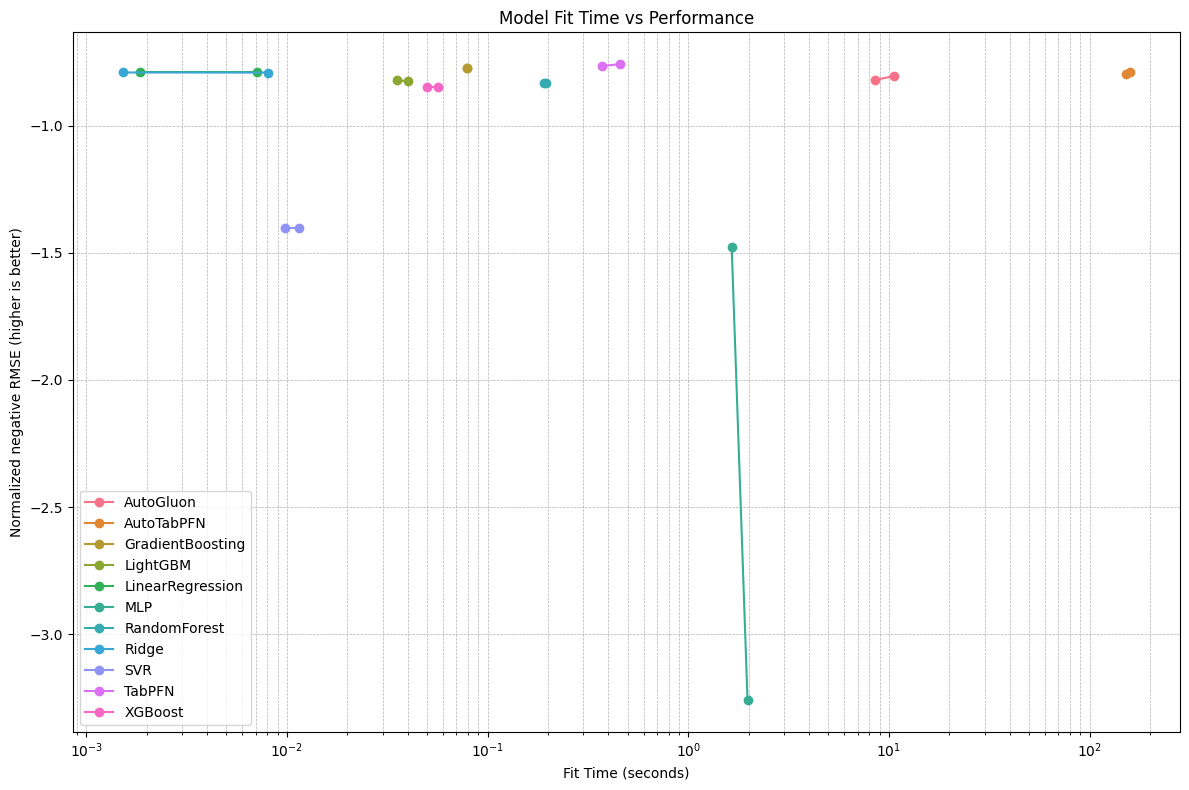

In [21]:
# --- Fit Time vs Normalized Negative RMSE Plot ---
metrics_df["BaseModel"] = metrics_df["Model"].apply(lambda x: "-".join(x.split("-")[:-1]))
metrics_df["NormNegRMSE"] = -metrics_df["RMSE"] / metrics_df["RMSE"].mean()

plt.figure(figsize=(12, 8))
palette = sns.color_palette("husl", metrics_df["BaseModel"].nunique())

for i, (model, group) in enumerate(metrics_df.groupby("BaseModel")):
    group = group.sort_values("FitTime")
    plt.plot(group["FitTime"], group["NormNegRMSE"],
             marker='o', label=model, color=palette[i])

plt.xscale("log")
plt.xlabel("Fit Time (seconds)")
plt.ylabel("Normalized negative RMSE (higher is better)")
plt.title("Model Fit Time vs Performance")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

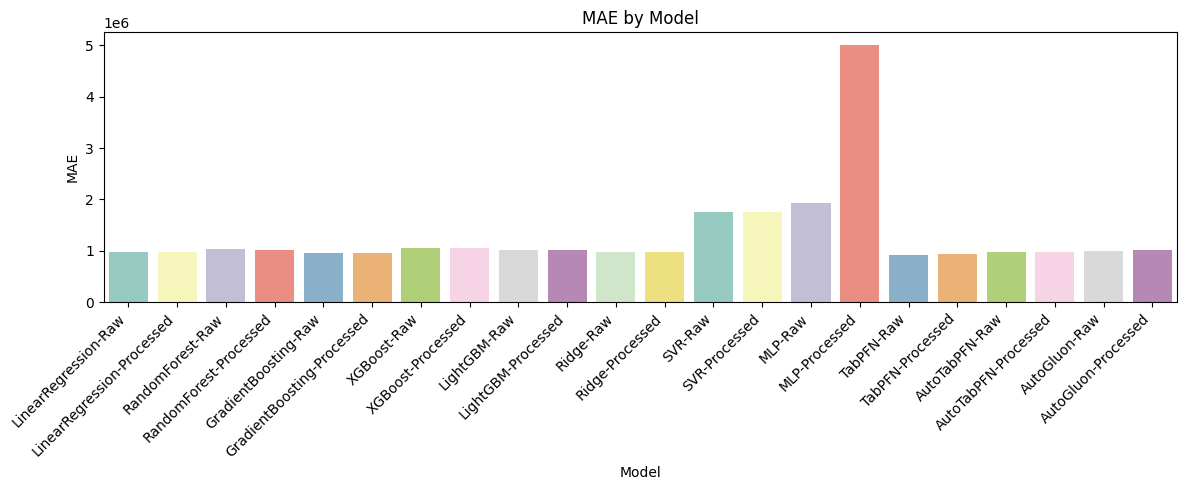

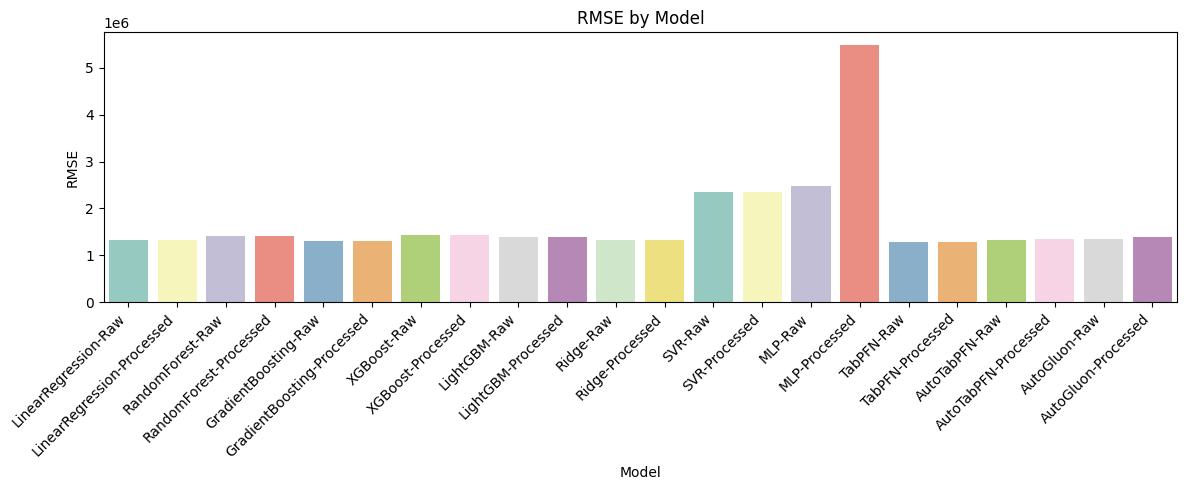

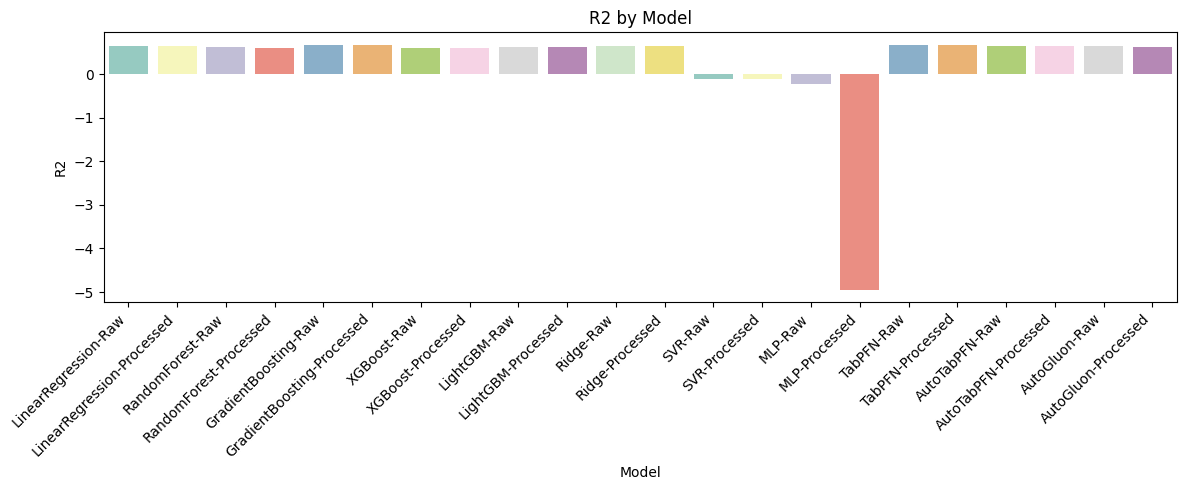

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = ["MAE", "RMSE", "R2"]
for metric in metrics_to_plot:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=metrics_df, x="Model", y=metric, palette="Set3")
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

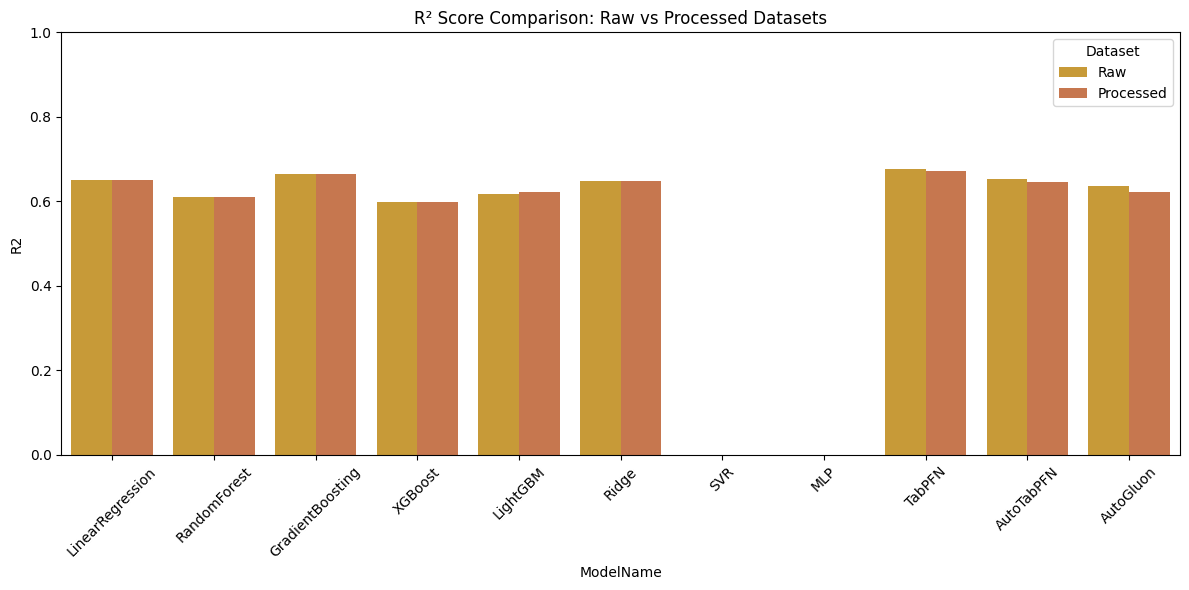

In [23]:
# Re-import necessary libraries after kernel reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

custom_palette = {
    "Raw": "#dfa320",
    "Processed": "#da713b"
}

# Split model type and dataset type
metrics_df[["ModelName", "Dataset"]] = metrics_df["Model"].str.split("-", expand=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x="ModelName", y="R2", hue="Dataset", palette=custom_palette)
plt.title("R² Score Comparison: Raw vs Processed Datasets")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Define binary classification thresholds
raw_thresh = raw_y_test.median()
proc_thresh = processed_y_test.median()

# Binarize targets
y_bin = {
    "Raw": (raw_y_test >= raw_thresh).astype(int),
    "Processed": (processed_y_test >= proc_thresh).astype(int)
}

# --- Define models and generate predictions ---
linear_model_raw = LinearRegression().fit(raw_X_train, raw_y_train)
linear_model_proc = LinearRegression().fit(processed_X_train, processed_y_train)
linreg_raw_preds = linear_model_raw.predict(raw_X_test)
linreg_proc_preds = linear_model_proc.predict(processed_X_test)

rf_model_raw = RandomForestRegressor(random_state=42).fit(raw_X_train, raw_y_train)
rf_model_proc = RandomForestRegressor(random_state=42).fit(processed_X_train, processed_y_train)
rf_raw_preds = rf_model_raw.predict(raw_X_test)
rf_proc_preds = rf_model_proc.predict(processed_X_test)

gb_model_raw = GradientBoostingRegressor(random_state=42).fit(raw_X_train, raw_y_train)
gb_model_proc = GradientBoostingRegressor(random_state=42).fit(processed_X_train, processed_y_train)
gb_raw_preds = gb_model_raw.predict(raw_X_test)
gb_proc_preds = gb_model_proc.predict(processed_X_test)

xgb_model_raw = xgb.XGBRegressor(random_state=42).fit(raw_X_train, raw_y_train)
xgb_model_proc = xgb.XGBRegressor(random_state=42).fit(processed_X_train, processed_y_train)
xgb_raw_preds = xgb_model_raw.predict(raw_X_test)
xgb_proc_preds = xgb_model_proc.predict(processed_X_test)

lgb_model_raw = lgb.LGBMRegressor(random_state=42).fit(raw_X_train, raw_y_train)
lgb_model_proc = lgb.LGBMRegressor(random_state=42).fit(processed_X_train, processed_y_train)
lgb_raw_preds = lgb_model_raw.predict(raw_X_test)
lgb_proc_preds = lgb_model_proc.predict(processed_X_test)

# TabPFN already predicted as raw_preds and proc_preds

In [25]:
# TabPFN
tabpfn_raw = TabPFNRegressor(device="cuda").fit(raw_X_train.values, raw_y_train.values)
raw_preds = tabpfn_raw.predict(raw_X_test.values)

tabpfn_proc = TabPFNRegressor(device="cuda").fit(processed_X_train.values, processed_y_train.values)
proc_preds = tabpfn_proc.predict(processed_X_test.values)

# AutoTabPFN
auto_model_raw = AutoTabPFNRegressor(device="cuda").fit(raw_X_train, raw_y_train)
auto_raw_preds = auto_model_raw.predict(raw_X_test)

auto_model_proc = AutoTabPFNRegressor(device="cuda").fit(processed_X_train, processed_y_train)
auto_proc_preds = auto_model_proc.predict(processed_X_test)

# AutoGluon
train_df_raw = raw_X_train.copy()
train_df_raw["target"] = raw_y_train
train_df_proc = processed_X_train.copy()
train_df_proc["target"] = processed_y_train

temp_dir_raw = tempfile.TemporaryDirectory()
temp_dir_proc = tempfile.TemporaryDirectory()

autogluon_model_raw = TabularPredictor(label="target", problem_type="regression", path=temp_dir_raw.name).fit(train_df_raw, verbosity=0)
autogluon_raw_preds = autogluon_model_raw.predict(raw_X_test)

autogluon_model_proc = TabularPredictor(label="target", problem_type="regression", path=temp_dir_proc.name).fit(train_df_proc, verbosity=0)
autogluon_proc_preds = autogluon_model_proc.predict(processed_X_test)

In [26]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Define binary classification thresholds
raw_thresh = raw_y_test.median()
proc_thresh = processed_y_test.median()

# Binarize targets
y_bin = {
    "Raw": (raw_y_test >= raw_thresh).astype(int),
    "Processed": (processed_y_test >= proc_thresh).astype(int)
}

# Predictions dictionary assumed (update these with your actual model predictions):
predictions = {
    "LinearRegression-Raw": linreg_raw_preds,
    "LinearRegression-Processed": linreg_proc_preds,
    "RandomForest-Raw": rf_raw_preds,
    "RandomForest-Processed": rf_proc_preds,
    "GradientBoosting-Raw": gb_raw_preds,
    "GradientBoosting-Processed": gb_proc_preds,
    "XGBoost-Raw": xgb_raw_preds,
    "XGBoost-Processed": xgb_proc_preds,
    "LightGBM-Raw": lgb_raw_preds,
    "LightGBM-Processed": lgb_proc_preds,
    "TabPFN-Raw": raw_preds,
    "TabPFN-Processed": proc_preds,
    "AutoTabPFN-Raw": auto_raw_preds,
    "AutoTabPFN-Processed": auto_proc_preds,
    "AutoGluon-Raw": autogluon_raw_preds,
    "AutoGluon-Processed": autogluon_proc_preds
}

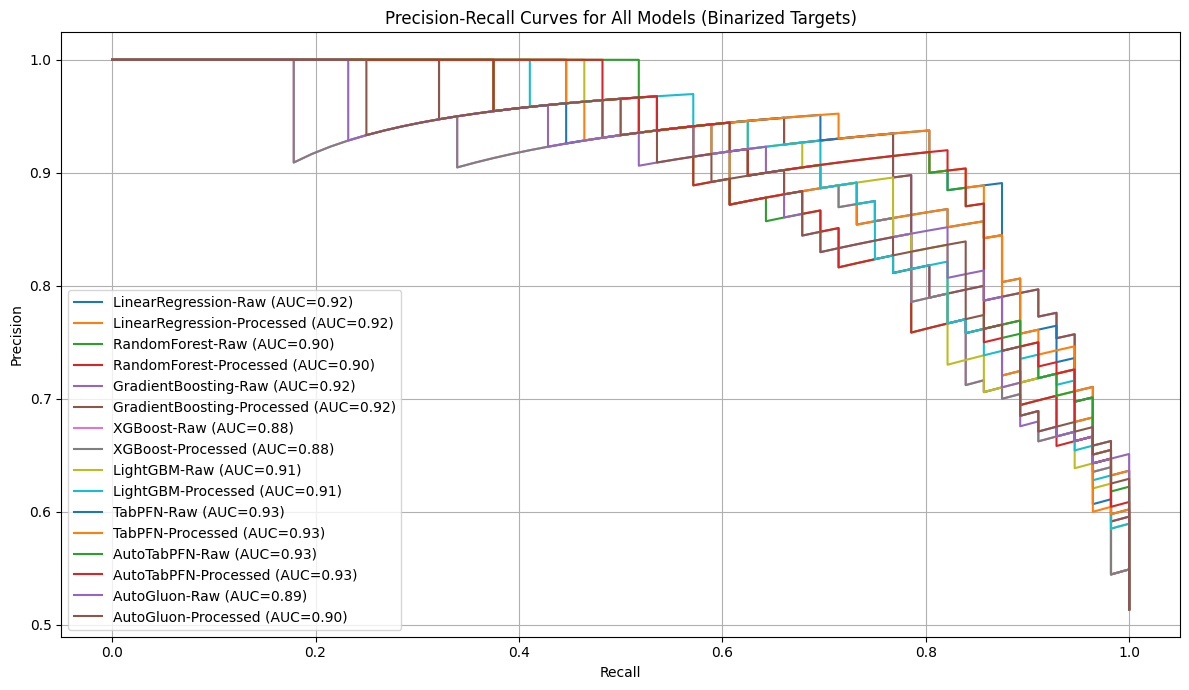

In [27]:
# Plot all PR curves
plt.figure(figsize=(12, 7))

for model_label, y_pred in predictions.items():
    dataset_type = "Raw" if "Raw" in model_label else "Processed"
    binary_y_true = y_bin[dataset_type]
    precision, recall, _ = precision_recall_curve(binary_y_true, y_pred)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{model_label} (AUC={pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for All Models (Binarized Targets)")
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
# %% [nan-check-fast] Quick sanity checks on arrays (works for DataFrame too via .to_numpy())
import numpy as np

def check_nonfinite(name, X, y=None):
    X = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
    print(f"\n[{name}] shape={X.shape}")

    n_nan = np.isnan(X).sum()
    n_inf = np.isinf(X).sum()
    n_rows_any_nonfinite = (~np.isfinite(X)).any(axis=1).sum()

    print(f"  X: NaN={n_nan:,}, ±Inf={n_inf:,}, rows with any non-finite={n_rows_any_nonfinite:,}")

    if y is not None:
        y = np.asarray(y).ravel()
        print(f"  y: NaN={(~np.isfinite(y)).sum():,} (of {y.size:,})")

# Use on your train/test
check_nonfinite("TRAIN", Xtr_np, ytr)
check_nonfinite("TEST",  Xte_np, yte)


[TRAIN] shape=(436, 12)
  X: NaN=0, ±Inf=0, rows with any non-finite=0
  y: NaN=0 (of 436)

[TEST] shape=(109, 12)
  X: NaN=0, ±Inf=0, rows with any non-finite=0
  y: NaN=0 (of 109)


In [34]:
# %% [fold-const-check]
import numpy as np
from sklearn.model_selection import KFold

def fold_constant_report(X, y, folds=3, near_std=1e-12):
    X = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
    y = np.asarray(y).ravel()
    kf = KFold(folds, shuffle=True, random_state=42)
    for i, (tr, va) in enumerate(kf.split(X, y), 1):
        std = np.nanstd(X[tr], axis=0)
        zero = int((std == 0.0).sum())
        near = int(((std > 0) & (std < near_std)).sum())
        print(f"Fold {i}: zero-var={zero}, near-const(<{near_std})={near}")

fold_constant_report(processed_X_train, processed_y_train, folds=3)

Fold 1: zero-var=0, near-const(<1e-12)=0
Fold 2: zero-var=0, near-const(<1e-12)=0
Fold 3: zero-var=0, near-const(<1e-12)=0



# 🔧 Hyperparameter Tuning Add‑On (Paper‑aligned search spaces)

This section **keeps your existing code** and **adds** optional hyperparameter tuning for baselines,
using ranges inspired by the TabPFN paper's baseline search spaces (MLP, RF, SVM, CatBoost, XGBoost, LightGBM).  
- Uses `RandomizedSearchCV` with log‑uniform/uniform distributions.  
- You can control the number of iterations per model via `N_ITER` (or set per‑model).  
- Works with your existing dataset variables (`X_train`, `X_test`, `y_train`, `y_test`) and your preprocessing choices.

> Tip: If your data pipeline variables are named differently, just adapt the `X_train`, `X_test`, `y_train`, `y_test` references below.

## To fix the LightBGM

In [38]:
# %% [setup] Imports & basic config
import numpy as np
import pandas as pd
import warnings, time

from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# Regressors
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

warnings.filterwarnings("ignore")

# Scoring for CV (neg RMSE; higher is better)
primary_scorer = "neg_root_mean_squared_error"

# Sanity: ensure your data variables exist
required = ["processed_X_train", "processed_X_test", "processed_y_train", "processed_y_test"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. Define your processed train/test splits before running.")

# Ensure NumPy arrays (so some libs ignore pandas column names cleanly)
Xtr_np = processed_X_train.to_numpy() if hasattr(processed_X_train, "to_numpy") else np.asarray(processed_X_train)
Xte_np = processed_X_test.to_numpy()  if hasattr(processed_X_test, "to_numpy")  else np.asarray(processed_X_test)
ytr    = np.asarray(processed_y_train).ravel()
yte    = np.asarray(processed_y_test).ravel()

print(f"Train: {Xtr_np.shape}, Test: {Xte_np.shape}")

Train: (436, 12), Test: (109, 12)


In [39]:
# %% [lgbm-wrapper] LightGBM with per-fit early stopping (quiet & CV-safe)
from sklearn.model_selection import train_test_split

class LGBMRegressorES(lgb.LGBMRegressor):
    """
    Wraps LGBMRegressor to perform an internal train/valid split for early stopping
    inside EACH fit call (i.e., for each CV fold), without any leakage.
    """
    def __init__(self, valid_size=0.12, es_rounds=50, random_state=42, n_jobs=1, **kwargs):
        super().__init__(random_state=random_state, n_jobs=n_jobs, **kwargs)
        self.valid_size = float(valid_size)
        self.es_rounds = int(es_rounds)

    def fit(self, X, y, **fit_params):
        X = np.asarray(X)
        y = np.asarray(y).ravel()
        Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=self.valid_size, random_state=42)
        return super().fit(
            Xtr, ytr,
            eval_set=[(Xval, yval)],
            callbacks=[lgb.early_stopping(self.es_rounds, verbose=False), lgb.log_evaluation(0)],
            **fit_params
        )

In [40]:
# %% [spaces] Paper-inspired search spaces (REGRESSION)
# Pipelines use ("model", <Regressor>), so hyperparams use "model__*"
search_spaces_reg = {
    "MLP": {
        "model__hidden_layer_sizes": [(h,) for h in [64, 128, 256]] + [(128, 64), (256, 128), (256, 128, 64)],
        "model__activation": ["relu", "tanh"],
        "model__alpha": loguniform(1e-7, 1e-1),
        "model__learning_rate_init": loguniform(1e-4, 10**-0.5),
        "model__early_stopping": [True, False],
        "model__max_iter": [300, 500, 800]
    },
    "RandomForest": {
        "model__n_estimators": randint(100, 1201),
        "model__max_depth": randint(3, 41),
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2", None]
    },
    "SVR": {
        "model__C": loguniform(1e-2, 1e3),
        "model__gamma": ["scale", "auto"],
        "model__epsilon": loguniform(1e-3, 1.0),
        "model__kernel": ["rbf", "poly", "sigmoid", "linear"]
    },
    "CatBoost": {
        "model__learning_rate": loguniform(1e-4, 0.5),
        "model__depth": randint(3, 11),
        "model__l2_leaf_reg": loguniform(1, 10),
        "model__random_strength": randint(1, 21),
        "model__bagging_temperature": uniform(0.0, 1.0),
        "model__iterations": randint(300, 4001)
    },
    "XGBoost": {
        "model__learning_rate": loguniform(1e-4, 0.3),
        "model__max_depth": randint(2, 11),
        "model__subsample": uniform(0.4, 0.6),         # 0.4..1.0
        "model__colsample_bytree": uniform(0.4, 0.6),  # 0.4..1.0
        "model__colsample_bylevel": uniform(0.4, 0.6),
        "model__min_child_weight": loguniform(1e-2, 1e2),
        "model__reg_alpha": loguniform(1e-8, 1e1),
        "model__reg_lambda": loguniform(1e-8, 1e1),
        "model__gamma": loguniform(1e-8, 1e1),
        "model__n_estimators": randint(200, 4001)
    },
    # >>> Safer, tighter LightGBM for small/medium tabular data <<<
    "LightGBM": {
        "model__num_leaves": randint(15, 63),
        "model__max_depth": randint(3, 11),
        "model__learning_rate": loguniform(1e-3, 0.2),
        "model__n_estimators": randint(150, 600),
        "model__min_child_samples": randint(5, 50),
        "model__min_child_weight": loguniform(1e-4, 10),
        "model__subsample": uniform(0.6, 0.4),         # 0.6..1.0
        "model__colsample_bytree": uniform(0.6, 0.4),  # 0.6..1.0
        "model__reg_alpha": loguniform(1e-8, 1e0),
        "model__reg_lambda": loguniform(1e-8, 1e0),
    },
    "Ridge": {
        "model__alpha": loguniform(1e-6, 1e3),
        "model__fit_intercept": [True, False]
    }
}

In [41]:
# %% [pipelines] Define estimator Pipelines (REGRESSION)
# Trees/boosters don't need scaling; linear/MLP/SVR benefit from it.
estimators_reg = {
    "MLP": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", MLPRegressor(random_state=42))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    "SVR": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", SVR())
    ]),
    "CatBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", cb.CatBoostRegressor(verbose=False, random_seed=42, loss_function="RMSE"))
    ]),
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", xgb.XGBRegressor(
            random_state=42,
            tree_method="hist",
            objective="reg:squarederror",
            n_jobs=-1
        ))
    ]),
    # LightGBM uses wrapper w/ per-fit early stopping + tiny variance filter
    "LightGBM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("vt", VarianceThreshold(0.0)),               # drop constant cols per CV split
        ("model", LGBMRegressorES(
            objective="rmse",                         # if version complains, use "regression"
            force_row_wise=True,
            n_jobs=1                                  # avoid CPU oversubscription vs outer CV
        ))
    ]),
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", Ridge(random_state=42))
    ])
}

# Search budget per model (can be tuned)
N_ITER_REG = {m: 30 for m in estimators_reg.keys()}
N_ITER_REG["LightGBM"] = 12  # lighter since ES already trims bad configs

In [42]:
# %% [run-hpo] Run tuning for all models and evaluate on the held-out TEST set
results_hpo_reg = []

for name, pipe in estimators_reg.items():
    print(f"\nTuning {name} ...")
    space = search_spaces_reg[name]
    n_iter = N_ITER_REG.get(name, 25)

    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=space,
        n_iter=n_iter,
        scoring=primary_scorer,   # neg RMSE
        cv=3,
        n_jobs=-1,                # parallelize CV across folds/configs
        verbose=2,                # show CV progress (quiet inside LGBM)
        random_state=42,
        refit=True
    )

    t0 = time.time()
    rs.fit(Xtr_np, ytr)          # wrapper handles ES internally for LightGBM
    fit_s = time.time() - t0

    best = rs.best_estimator_
    yhat = best.predict(Xte_np)

    mae  = mean_absolute_error(yte, yhat)
    rmse = mean_squared_error(yte, yhat, squared=False)
    r2   = r2_score(yte, yhat)

    results_hpo_reg.append({
        "model": f"{name} (tuned)",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "fit_s": fit_s,
        "best_params": rs.best_params_
    })

results_hpo_reg = pd.DataFrame(results_hpo_reg).sort_values(
    ["RMSE", "MAE", "R2"], ascending=[True, True, False]
).reset_index(drop=True)

display(results_hpo_reg)


Tuning MLP ...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro


Tuning RandomForest ...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END model__activation=relu, model__alpha=0.006015308718396459, model__early_stopping=True, model__hidden_layer_sizes=(256,), model__learning_rate_init=0.05356961201569894, model__max_iter=300; total time=   1.2s
[CV] END model__activation=tanh, model__alpha=1.102548826429165e-07, model__early_stopping=True, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.006866118759430415, model__max_iter=800; total time=   0.0s
[CV] END model__activation=tanh, model__alpha=1.102548826429165e-07, model__early_stopping=True, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.006866118759430415, model__max_iter=800; total time=   0.0s
[CV] END model__activation=tanh, model__alpha=1.102548826429165e-07, model__early_stopping=True, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.006866118759430415, model__max_iter=800; total time=   0.0s
[CV] END model__activation=tanh, model__alp

,model,MAE,RMSE,R2,fit_s,best_params
0,Ridge (tuned),9.796377e+05,1.331141e+06,0.649439,0.183713,"{'model__alpha': 0.3197999889429477, 'model__fit_intercept': True}"
1,XGBoost (tuned),9.491067e+05,1.331637e+06,0.649178,24.260426,"{'model__colsample_bylevel': 0.5709042966264806, 'model__colsample_bytree': 0.4221321684127197, 'model__gamma': 0.003062520509464317, 'model__learning_rate': 0.005595976937366778, 'model__max_depth': 7, 'model__min_child_weight': 0.013558227959926897, 'model__n_estimators': 1959, 'model__reg_alpha': 1.49414578394363, 'model__reg_lambda': 1.4323759352560882e-06, 'model__subsample': 0.48693692325473387}"
2,MLP (tuned),1.009726e+06,1.350086e+06,0.639389,43.380116,"{'model__activation': 'relu', 'model__alpha': 0.0021398194315034413, 'model__early_stopping': True, 'model__hidden_layer_sizes': (256, 128, 64), 'model__learning_rate_init': 0.005349147669573061, 'model__max_iter': 300}"
3,CatBoost (tuned),1.024974e+06,1.383281e+06,0.621438,163.594023,"{'model__bagging_temperature': 0.013264961159866528, 'model__depth': 3, 'model__iterations': 2663, 'model__l2_leaf_reg': 3.658374977026927, 'model__learning_rate': 0.0026646739856563376, 'model__random_strength': 2}"
4,RandomForest (tuned),1.027550e+06,1.396825e+06,0.613989,37.614707,"{'model__max_depth': 8, 'model__max_features': 'log2', 'model__min_samples_split': 5, 'model__n_estimators': 802}"
5,LightGBM (tuned),1.031816e+06,1.407201e+06,0.608233,3.707238,"{'model__colsample_bytree': 0.7799016533479063, 'model__learning_rate': 0.008114327755581423, 'model__max_depth': 6, 'model__min_child_samples': 18, 'model__min_child_weight': 0.4328724829857118, 'model__n_estimators': 420, 'model__num_leaves': 22, 'model__reg_alpha': 0.00036605959530379434, 'model__reg_lambda': 0.00014678243236193207, 'model__subsample': 0.9844688097397396}"
6,SVR (tuned),1.404166e+06,1.930926e+06,0.262356,0.389726,"{'model__C': 859.8737339212263, 'model__epsilon': 0.2073644517790503, 'model__gamma': 'auto', 'model__kernel': 'linear'}"


In [43]:
# %% [save] Save results and pretty-print best params
out_csv_reg = "regression_hparam_tuned_results.csv"
results_hpo_reg.to_csv(out_csv_reg, index=False)
print("Saved tuned results to:", out_csv_reg)

for i, r in results_hpo_reg.iterrows():
    print("\n===", r["model"], "===")
    for k, v in r["best_params"].items():
        print(f"{k}: {v}")

Saved tuned results to: regression_hparam_tuned_results.csv

=== Ridge (tuned) ===
model__alpha: 0.3197999889429477
model__fit_intercept: True

=== XGBoost (tuned) ===
model__colsample_bylevel: 0.5709042966264806
model__colsample_bytree: 0.4221321684127197
model__gamma: 0.003062520509464317
model__learning_rate: 0.005595976937366778
model__max_depth: 7
model__min_child_weight: 0.013558227959926897
model__n_estimators: 1959
model__reg_alpha: 1.49414578394363
model__reg_lambda: 1.4323759352560882e-06
model__subsample: 0.48693692325473387

=== MLP (tuned) ===
model__activation: relu
model__alpha: 0.0021398194315034413
model__early_stopping: True
model__hidden_layer_sizes: (256, 128, 64)
model__learning_rate_init: 0.005349147669573061
model__max_iter: 300

=== CatBoost (tuned) ===
model__bagging_temperature: 0.013264961159866528
model__depth: 3
model__iterations: 2663
model__l2_leaf_reg: 3.658374977026927
model__learning_rate: 0.0026646739856563376
model__random_strength: 2

=== RandomFore